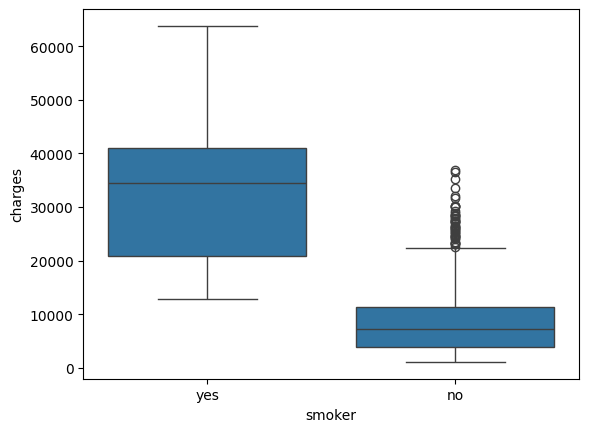

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# The dataset contains medical insurance information including demographic
# and lifestyle variables used to predict medical charges
df = pd.read_csv("insurance.csv")

# EDA here
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# Inspect dataset structure
# View first 5 rows to understand data format
print(df.head())
# Check data types and missing values
print(df.info())
# Summary statistics for numerical variables
print(df.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


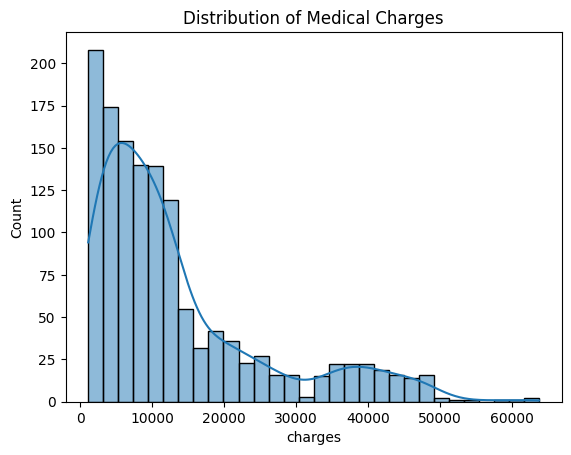

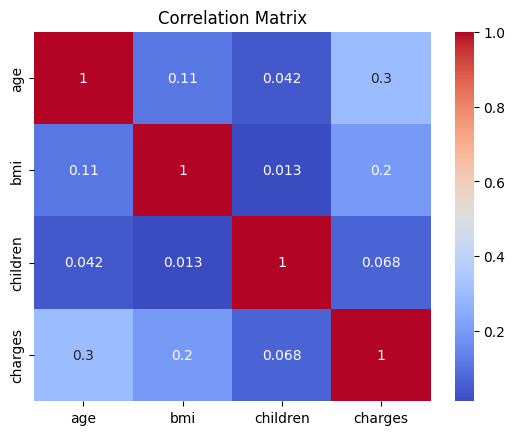

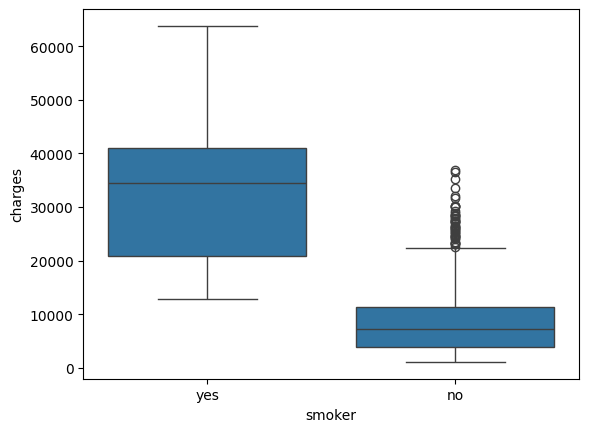

In [38]:
# Check missing values
# Ensures dataset quality before modelling
print(df.isnull().sum())

# Distribution of charges
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

# Correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Boxplot for smoker vs charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

**Insights**

Smokers have significantly higher charges

Charges are right-skewed (may require log transformation)

Age moderately correlates with charges

In [30]:
# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.7835929767120723
MAE: 4181.194473753654
RMSE: 5796.2846592762735


## Interpretation

R² close to 1 - strong predictive power

Low MAE/RMSE - accurate predictions

In [35]:
# Log transformation to handle skewness
y_log = np.log(df['charges'])

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Improved R2:", r2_score(y_test, y_pred))

Improved R2: 0.8047311493462987


## Improvement Explanation

Log transformation reduces skewness

Improves model accuracy and stability

## Executive Summary

The analysis developed a predictive model to estimate medical aid costs based on demographic and lifestyle factors. The model demonstrated strong predictive capability, with smoking identified as the most significant cost driver.

### Key Findings

Smoking significantly increases medical costs
Age and BMI moderately influence charges
Region has minimal impact

### Model Performance
R²: High (strong fit)
RMSE: Acceptable error range

### Recommendations.

Introduce risk-based pricing for smokers
Encourage wellness programmes to reduce BMI
Use predictive models for customer segmentation.

### Limitations

Dataset is US-based (may not fully reflect South Africa)
Small number of variables
External socio-economic factors not included